<a href="https://colab.research.google.com/github/vaishnavi-gujare/Dataframe-projects/blob/main/Session16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploded = files.upload()

Saving insurance.xlsx to insurance.xlsx


In [3]:
filepath = "/content/insurance.xlsx"
df = pd.read_excel(filepath)

In [ ]:
df.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [ ]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_columns)

categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['age', 'bmi', 'children', 'expenses'], dtype='object')
Index(['sex', 'smoker', 'region'], dtype='object')


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

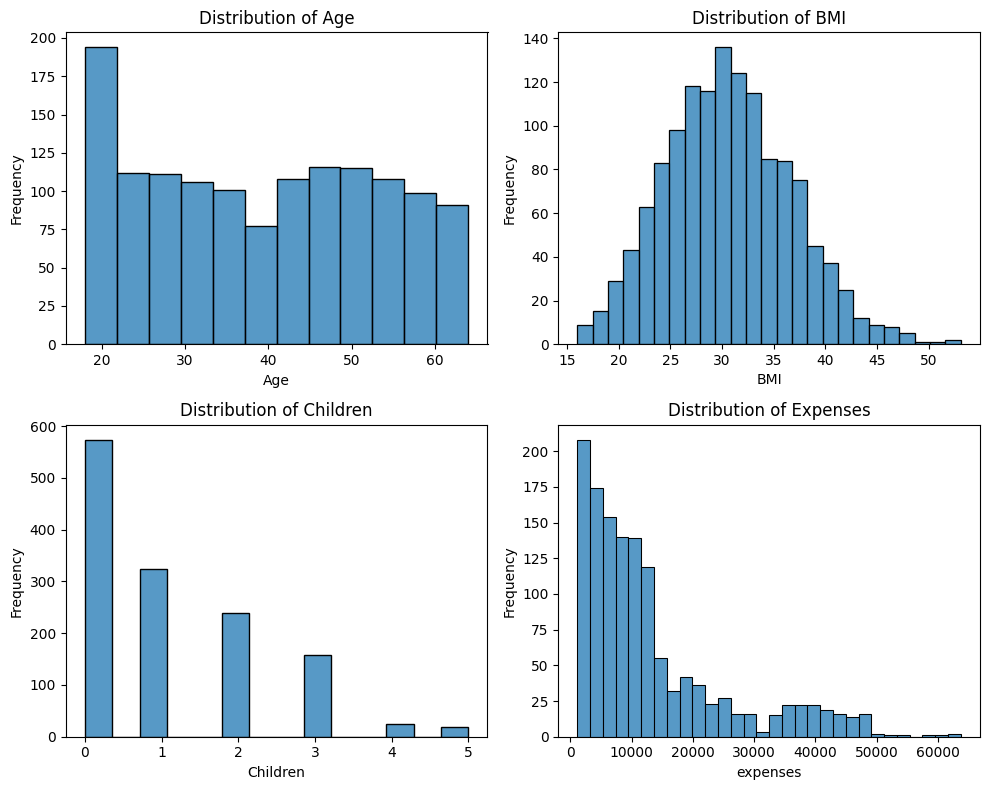

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['age'])
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(df['bmi'])
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.histplot(df['children'])
plt.title('Distribution of Children')
plt.xlabel('Children')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.histplot(df['expenses'])
plt.title('Distribution of Expenses')
plt.xlabel('expenses')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

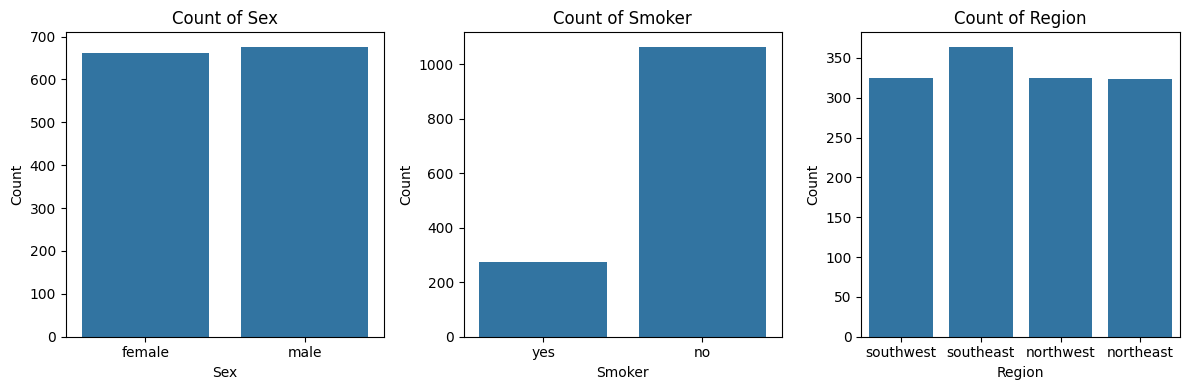

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(x='sex', data=df)
plt.title('Count of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.countplot(x='smoker', data=df)
plt.title('Count of Smoker')
plt.xlabel('Smoker')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.countplot(x='region', data=df)
plt.title('Count of Region')
plt.xlabel('Region')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

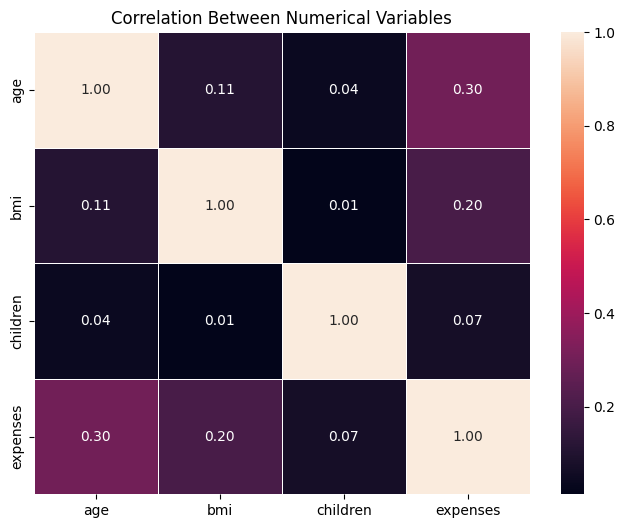

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Between Numerical Variables')
plt.show()

In [8]:
print("Average expenses:", df['expenses'].mean())
print("Maximum expenses:", df['expenses'].max())
print("Minimum expenses:", df['expenses'].min())

comparison = df.groupby('smoker').agg(Average_expenses=('expenses', 'mean'))
print(comparison)

Average expenses: 13270.422414050823
Maximum expenses: 63770.43
Minimum expenses: 1121.87
        Average_expenses
smoker                  
no           8434.268449
yes         32050.231971


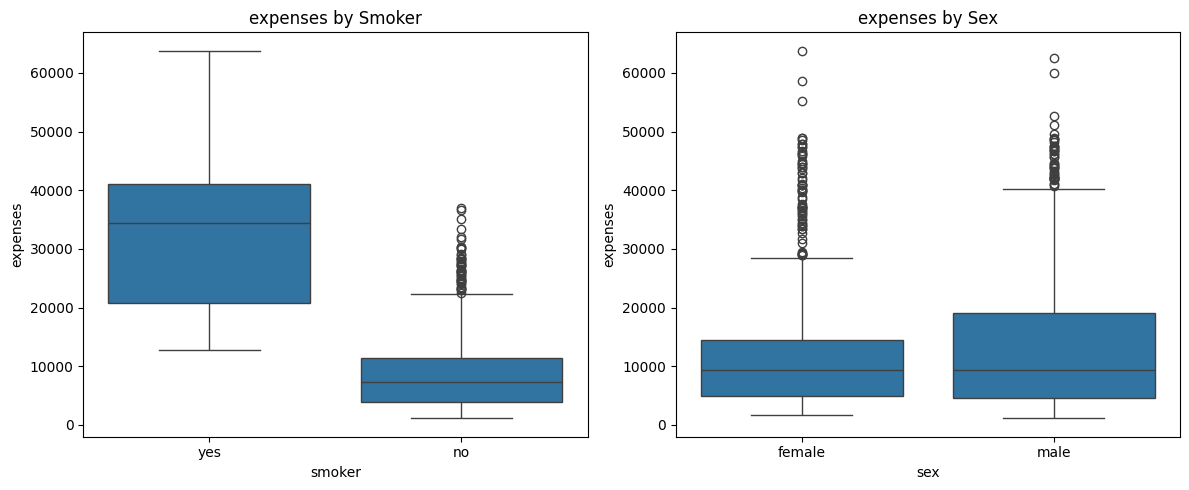

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='smoker', y='expenses', data=df)
plt.title('expenses by Smoker')

plt.subplot(1, 2, 2)
sns.boxplot(x='sex', y='expenses', data=df)
plt.title('expenses by Sex')

plt.tight_layout()
plt.show()

In [14]:
print("Average Age:", df['age'].mean())
print("Average BMI:", df['bmi'].mean())

print(df['region'].value_counts())

Average Age: 39.20702541106129
Average BMI: 30.66547085201794
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
